<a href="https://colab.research.google.com/github/lescalona/InmersionAgentes/blob/main/Inmersion_Agentes_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q google-genai

In [ ]:
from google.colab import userdata
import os

os.environ['GEMINI_API_KEY'] = userdata.get('GEMINI_API_KEY')

In [ ]:
from google import genai

cliente = genai.Client()

In [ ]:
respuesta = cliente.models.generate_content(
    model = "gemini-2.5-flash",
    contents = "Cual es la capital de Venezuela"
)
print(respuesta.text)

La capital de Venezuela es **Caracas**.


In [ ]:
from google.colab import files
os.makedirs("PDFs", exist_ok=True)
uploader = files.upload()

for archivo in uploader.keys():
  os.rename(archivo, f"PDFs/{archivo}")

Saving Reporte Comisiones Marzo 2026.pdf to Reporte Comisiones Marzo 2026.pdf
Saving Reporte Comisiones Mayo 2026.pdf to Reporte Comisiones Mayo 2026.pdf
Saving Reporte Comisiones Abril 2026.pdf to Reporte Comisiones Abril 2026.pdf
Saving Reporte Comisiones Junio 2026.pdf to Reporte Comisiones Junio 2026.pdf


In [ ]:
!pip install -q langchain-community pypdf

In [ ]:
from langchain_community.document_loaders import PyPDFLoader

In [ ]:
from os.path import join
documentos = []

for archivo2 in os.listdir("PDFs"):
  ruta = os.path.join("PDFs",archivo2)
  loader = PyPDFLoader(ruta)
  paginas = loader.load()
  documentos.extend(paginas)

In [ ]:
documentos[0]

Document(metadata={'producer': 'Microsoft® Excel® for Microsoft 365', 'creator': 'Microsoft® Excel® for Microsoft 365', 'creationdate': '2026-03-17T16:51:09-03:00', 'author': 'Luisa Mercedes Escalona Rivero', 'moddate': '2026-03-17T16:51:09-03:00', 'source': 'PDFs/Reporte Comisiones Marzo 2026.pdf', 'total_pages': 1, 'page': 0, 'page_label': '1'}, page_content='Nombre de Cobrador Planilla Usuario Comision Fecha \nABELLONIO AGUSTIN ALEJANDRO 886713 382728 5340,00 05/03/2026\nABELLONIO AGUSTIN ALEJANDRO 886713 410072 5340,00 05/03/2026\nABELLONIO AGUSTIN ALEJANDRO 888801 463112 725000,00 06/03/2026\nABELLONIO AGUSTIN ALEJANDRO 892436 466372 42500,00 09/03/2026\nABELLONIO AGUSTIN ALEJANDRO 887570 133573 14166,78 21/03/2026\nABELLONIO AGUSTIN ALEJANDRO 887570 255401 14166,78 21/03/2026\nABELLONIO AGUSTIN ALEJANDRO 888628 95319 6610,44 25/03/2026\nABELLONIO AGUSTIN ALEJANDRO 888628 387697 6610,44 25/03/2026\nABELLONIO AGUSTIN ALEJANDRO 888628 95320 6610,44 25/03/2026\nACERBI FERNANDO 888881

In [ ]:
len(documentos)

4

In [ ]:
!pip install -q langchain-text-splitters

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

divisor = RecursiveCharacterTextSplitter(
    chunk_size = 400,
    chunk_overlap = 40,
    separators=["\n\n", "\n","."," ",""]
)

fragmentos = divisor.split_documents(documentos)

In [ ]:
fragmentos[5]

Document(metadata={'producer': 'Microsoft® Excel® for Microsoft 365', 'creator': 'Microsoft® Excel® for Microsoft 365', 'creationdate': '2026-03-17T16:48:59-03:00', 'author': 'Luisa Mercedes Escalona Rivero', 'moddate': '2026-03-17T16:48:59-03:00', 'source': 'PDFs/Reporte Comisiones Mayo 2026.pdf', 'total_pages': 1, 'page': 0, 'page_label': '1'}, page_content='Nombre de Cobrador Planilla Usuario Comision Fecha \nABELLONIO AGUSTIN ALEJANDRO 886713 382728 5340,08 05/05/2026\nABELLONIO AGUSTIN ALEJANDRO 886713 410072 5340,08 05/05/2026\nABELLONIO AGUSTIN ALEJANDRO 888628 387697 6610,44 25/05/2026\nABELLONIO AGUSTIN ALEJANDRO 888628 95319 6610,44 25/05/2026\nABELLONIO AGUSTIN ALEJANDRO 888628 95320 6610,44 25/05/2026')

In [ ]:
!pip install -q langchain-google-genai faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 35.3 MB/s eta 0:00:00


In [ ]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_community.vectorstores import FAISS

embeddings = GoogleGenerativeAIEmbeddings(
    model = "models/gemini-embedding-001"
)

In [ ]:
vectorstore = FAISS.from_documents(
    documents = fragmentos,
    embedding = embeddings
)

In [ ]:
vectorstore.index.reconstruct(0)

array([-0.02744312,  0.01537557,  0.03260863, ...,  0.01298548,
       -0.00960968, -0.01937812], dtype=float32)

In [ ]:
len(vectorstore.index.reconstruct(0))

3072

In [ ]:
consulta = "Cual es la comision de AQUINO LUIS?"
resultados = vectorstore.similarity_search(
    consulta,
    k = 3
)

for i in resultados:
  print(i)
  print("\n")


page_content='AQUINO LUIS 892147 306585 1485,02 22/04/2026' metadata={'producer': 'Microsoft® Excel® for Microsoft 365', 'creator': 'Microsoft® Excel® for Microsoft 365', 'creationdate': '2026-03-17T16:48:04-03:00', 'author': 'Luisa Mercedes Escalona Rivero', 'moddate': '2026-03-17T16:48:04-03:00', 'source': 'PDFs/Reporte Comisiones Abril 2026.pdf', 'total_pages': 1, 'page': 0, 'page_label': '1'}


page_content='Nombre de Cobrador Planilla Usuario Comision Fecha 
ABELLONIO AGUSTIN ALEJANDRO 886713 382728 5340,00 05/03/2026
ABELLONIO AGUSTIN ALEJANDRO 886713 410072 5340,00 05/03/2026
ABELLONIO AGUSTIN ALEJANDRO 888801 463112 725000,00 06/03/2026
ABELLONIO AGUSTIN ALEJANDRO 892436 466372 42500,00 09/03/2026
ABELLONIO AGUSTIN ALEJANDRO 887570 133573 14166,78 21/03/2026' metadata={'producer': 'Microsoft® Excel® for Microsoft 365', 'creator': 'Microsoft® Excel® for Microsoft 365', 'creationdate': '2026-03-17T16:51:09-03:00', 'author': 'Luisa Mercedes Escalona Rivero', 'moddate': '2026-03-17

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI
llm = ChatGoogleGenerativeAI(
    model = "gemini-2.5-flash",
    temperature = 0.2
)

recuperador = vectorstore.as_retriever(
    search_kwargs= {"k":4}
)


In [ ]:
def preguntar_rag(pregunta):
  docs = recuperador.invoke(pregunta)
  contexto = "\n\n--\n\n".join(doc.page_content for doc in docs)

  prompt = f"""Eres un asistente experto que responde preguntas basandose UNICAMENTE en el contexto proporcionado.
  Si la informacion no esta en el contexto, di que no tienes suficiente informacion.
  Contexto: {contexto}.

  Pregunta: {pregunta}.  Respuesta: """

  respuesta = llm.invoke(prompt)
  return respuesta.content




In [ ]:
preguntar_rag("Cual es la comision del dia 05/03/2026?")

'Las comisiones del día 05/03/2026 son: 5340,00 y 5340,00.'

In [ ]:
!pip install -q langgraph google-search-results markdown fpdf2

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.0/81.0 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 6.9 MB/s eta 0:00:00


In [ ]:
os.environ['SERPAPI_API_KEY'] = userdata.get('SERPAPI_API_KEY')

In [ ]:
from langchain_community.utilities import SerpAPIWrapper
buscador = SerpAPIWrapper()
resp = buscador.run("Quien gano el clasico mundial de beisbol 2026?")
resp

[{'title': 'Venezuela 3-2 Estados Unidos | En vivo, hoy: Final del Clásico Mundial de Béisbol 2026; WBC en directo',
  'link': 'https://as.com/us/mlb/estados-unidos-0-0-venezuela-en-vivo-resultado-de-la-final-del-clasico-mundial-de-beisbol-carreras-y-datos-en-directo-hoy-f202603-d/',
  'source': 'Diario AS',
  'source_logo': 'https://serpapi.com/searches/69bb23f449579af3137d421c/images/p5l5Vv8mKrpVm3dTLoYiVUP-joVyYm2XfKLxkNX1_-Q.png',
  'date': '16 hours ago'},
 {'title': 'Maikel García nombrado JMV del Clásico Mundial de Béisbol 2026',
  'link': 'https://www.mlb.com/es/world-baseball-classic/news/maikel-garcia-gana-el-jmv-del-clasico-mundial-de-beisbol-2026',
  'source': 'MLB.com',
  'source_logo': 'https://serpapi.com/searches/69bb23f449579af3137d421c/images/T-AaqP-7S9H9opztqNYVgRtNQ9WTMWbiyDeZdyfuZvk.png',
  'date': '18 hours ago'},
 {'title': 'Clásico Mundial de Béisbol 2026: resultados, clasificados, bracket de la fase final y semifinales',
  'link': 'https://as.com/us/mlb/clasico

In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

class AgentState(TypedDict):
  pregunta: str
  fuente: str
  contexto: str
  respuesta: str


In [ ]:
def nodo_agente(state: AgentState):
  pregunta = state["pregunta"]

  prompt = f"""Eres un clasificador. Dada la siguiente pregunta, decide si debe responder
  buscando en los documentos locales (PDFs cargados) de la empresa AADI CAPIF o informaciones
  mas generales en la WEB (internet).
  Reglas:
  - Responde SOLO con la palabra 'RAG' si la pregunta se refiere al contenido de documentos cargados.
  - Responde SOLO con la palabra 'Web' si la pregunta requiere informacion actualizada de temas generales
    de la WEB.

  Pregunta: {pregunta}.
  Respuesta (RAG o Web): """

  respuesta = llm.invoke(prompt)

  fuente = respuesta.content.strip()

  if "RAG" in fuente:
    fuente = "RAG"
  else:
    fuente = "Web"

  print(f"El agente decidio la fuente: {fuente}")
  return {"fuente": fuente}





In [ ]:
def nodo_rag(state: AgentState):
  contexto = preguntar_rag(state["pregunta"])
  return { "contexto": contexto}

In [ ]:
def nodo_web(state: AgentState):
  contexto = buscador.run(state["pregunta"])
  return { "contexto": contexto}

In [ ]:
def nodo_markdown(state: AgentState):
  prompt = f"""Eres un saistente experto. Genera una respuesta completa y bien formateada
  en Markdown basandote en el contexto proporcionado.
  Incluye: título (#), subtítulo (##), listas y negritas donde corresponda.
  Responde siempre en español.

  Contexto (fuente: {state["fuente"]}):
  {state["contexto"]}.

  Pregunta: {state["pregunta"]}.

  Respuesta en Markdown: """

  respuesta = llm.invoke(prompt)
  return {"respuesta": respuesta.content}

In [ ]:
def decidir_fuente(state: AgentState):
  if state["fuente"] == "RAG":
    return "Rag_elegido"
  elif state["fuente"] == "Web":
    return "Web_elegido"
  else:
    return "Error"


In [ ]:
grafo = StateGraph(AgentState)
grafo.add_node("Agente",nodo_agente)
grafo.add_node("RAG",nodo_rag)
grafo.add_node("Web",nodo_web)
grafo.add_node("Markdown",nodo_markdown)
grafo.add_edge(START, "Agente")
grafo.add_conditional_edges("Agente", decidir_fuente,
                            {"Rag_elegido":"RAG",
                            "Web_elegido": "Web"})
grafo.add_edge("RAG","Markdown")
grafo.add_edge("Web","Markdown")
grafo.add_edge("Markdown", END)

In [ ]:
agente = grafo.compile()

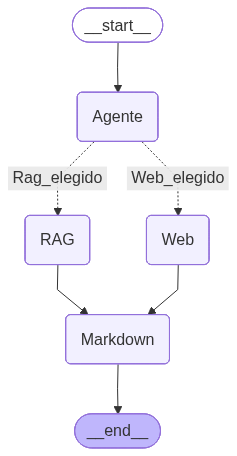

In [ ]:
from IPython.display import Image, display
imagen = agente.get_graph().draw_mermaid_png()
display(Image(imagen))

In [ ]:
def ejecutar_agente(pregunta):
  resultado = agente.invoke({
      "pregunta": pregunta,
      "fuente": "",
      "contexto": "",
      "respuesta": ""
  })

  respuesta_final = resultado["respuesta"]

  print("=" * 60)
  print(f"Fuente utilizada: {resultado["fuente"]}")
  print("=" * 60)
  print(f"Contexto utilizado: {resultado["contexto"]}")
  print("=" * 60)
  print(f"Respuesta final: {respuesta_final}")

  return respuesta_final

In [ ]:
markdown_texto = ejecutar_agente("Cual es la comision del dia 05/03/2026?")

El agente decidio la fuente: RAG
Fuente utilizada: RAG
Contexto utilizado: La comisión del día 05/03/2026 es 10680,00.
Respuesta final: # Comisión del Día 05/03/2026

## Detalle de la Comisión

Basándonos en la información proporcionada, la comisión correspondiente al día **05 de marzo de 2026** es la siguiente:

*   **Fecha:** 05/03/2026
*   **Monto de la Comisión:** **10.680,00**


In [ ]:
!pip install -q markdown2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.2/56.2 kB 2.2 MB/s eta 0:00:00


In [ ]:
from fpdf import FPDF, HTMLMixin
import markdown2

def exportar_markdown_pdf(texto, nombre_archivo):
    pdf = FPDF()
    pdf.add_page()
    pdf.set_font("Helvetica", size=12)

    # Convertir Markdown a HTML
    html = markdown2.markdown(texto)

    # Renderizar HTML en el PDF
    pdf.write_html(html)

    pdf.output(nombre_archivo)

In [ ]:
exportar_markdown_pdf(markdown_texto,"resultado.pdf")